In this notebook, a recommendation system is built to:

- Return the top *k* dishes based on a user query.
- Display recommended dishes when the user enters the site, based on their previous orders.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
working_directory = "/content/drive/MyDrive/transformers/Restaurant/Find_Meals"

In [4]:
os.chdir(working_directory)

In [5]:
os.getcwd()

'/content/drive/MyDrive/transformers/Restaurant/Find_Meals'

In [6]:
!ls

cosine_similarity_matrix.ipynb	indian_food.zip
cosine_similarity_matrix.npy	meal_recommendation_system.ipynb
indian_food.csv			product_embeddings.npy


In [7]:
df = pd.read_csv("./indian_food.csv")

In [8]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [10]:
embeddings = np.load("./product_embeddings.npy")

In [11]:
embeddings

array([[ 0.0163672 ,  0.05465626,  0.03164252, ...,  0.02864694,
         0.00851698, -0.02645836],
       [-0.00554581,  0.01783556,  0.06132139, ...,  0.02343436,
         0.02231711, -0.01004459],
       [ 0.01632514,  0.08825903,  0.00926736, ...,  0.02608406,
        -0.03759384, -0.02179034],
       ...,
       [ 0.0074555 ,  0.07032397,  0.03712026, ...,  0.03917303,
        -0.00517352,  0.02663715],
       [ 0.03465152, -0.00861237,  0.03045205, ..., -0.00079639,
         0.02357826, -0.00452019],
       [ 0.03357434,  0.0305451 ,  0.05412727, ..., -0.0217205 ,
         0.02458404,  0.00946234]], dtype=float32)

In [12]:
similarity_matrix = np.load("./cosine_similarity_matrix.npy")

In [13]:
similarity_matrix

array([[1.        , 0.8312722 , 0.7901525 , ..., 0.8049377 , 0.84266615,
        0.67274094],
       [0.8312722 , 1.        , 0.7843121 , ..., 0.7976359 , 0.8211512 ,
        0.7258732 ],
       [0.7901525 , 0.7843121 , 0.99999994, ..., 0.7554959 , 0.71699333,
        0.6528256 ],
       ...,
       [0.8049377 , 0.7976359 , 0.7554959 , ..., 0.9999999 , 0.77195626,
        0.69954675],
       [0.84266615, 0.8211512 , 0.71699333, ..., 0.77195626, 1.0000002 ,
        0.7095849 ],
       [0.67274094, 0.7258732 , 0.6528256 , ..., 0.69954675, 0.7095849 ,
        1.        ]], dtype=float32)

# 1. Display top dishes based on semantic meaning

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [15]:
model_name= "distiluse-base-multilingual-cased-v1"

In [ ]:
embedding_model = SentenceTransformer(model_name)

In [17]:
def get_top_dishes_indices_by_similarity(user_search, model = embedding_model, embeddings = embeddings,top_k = 10):
  user_embedding = model.encode([user_search])
  similarities = cosine_similarity(user_embedding, embeddings)
  similarities = similarities[0]
  top_indices = np.argsort(similarities)[-top_k:][::-1]
  return top_indices



###  Now it’s time to test

In [18]:
user_search = "vegetarian dish, spicy flavor, main course"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
152,Poriyal,"Chana dal, urad dal, beans, coconut, mustard",spicy,main course
223,Kumol Sawul,"Rice, eggs, carrot, beetroot",spicy,main course
137,Beef Fry,"Beef, coconut, garam masala, curry leaves, gre...",spicy,main course
194,Laapsi,"Cinnamon, jaggery, clarified butter, dry roasted",spicy,main course
138,Kootu,"Chana dal, urad dal, potato, beans, peas",spicy,main course
70,Aloo matar,"Potato, peas, chillies, ginger, garam masala, ...",spicy,main course
210,Veg Kolhapuri,"Gobi, potato, beans, khus khus, coconut",spicy,main course
166,Zunka,"Gram flour, mustard, garlic, turmeric, red chilli",spicy,main course
195,Koshimbir,"Cucumber, carrot, tomatoes, cilantro",spicy,main course
225,Alu Pitika,"Potatoes, mustard oil, fish, green chillies",spicy,main course


In [19]:
user_search = "sweet indian dessert with milk"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
29,Misti doi,"Milk, jaggery",sweet,dessert
40,Dharwad pedha,"Milk, Sugar, Dharwadi buffalo milk",sweet,dessert
8,Kalakand,"Milk, cottage cheese, sugar",sweet,dessert
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",sweet,dessert
170,Coconut vadi,"Condensed milk, mawa, desiccated coconut, almo...",sweet,dessert
47,Palathalikalu,"Rice flour, milk",sweet,dessert
58,Doodhpak,"Milk, rice, sugar, dry fruits",sweet,dessert
21,Chhena kheeri,"Chhena, sugar, milk",sweet,dessert
45,Mysore pak,"Besan flour, semolina, mung bean, jaggery, coc...",sweet,dessert
11,Lassi,"Yogurt, milk, nuts, sugar",sweet,dessert


In [20]:
user_search = "creamy curry made with paneer, butter, tomato sauce, cream, and mild spices"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
132,Kaara kozhambu,"Sesame oil, drumstick, tamarind paste, sambar ...",spicy,main course
107,Paneer butter masala,"Paneer, whipping cream, garam masala, cashew n...",spicy,main course
183,Gatta curry,"Yogurt, besan, sauce, garam masala powder, gra...",spicy,main course
74,Bhindi masala,"Ladies finger, garam masala, kasuri methi, tom...",spicy,main course
108,Paneer tikka masala,"Paneer, greek yogurt, tandoori masala, cream, ...",spicy,main course
91,Kadai paneer,"Cottage cheese, bell peppers, gravy, garam mas...",spicy,main course
92,Kadhi pakoda,"Besan, garam masala powder, gram flour, ginger...",spicy,main course
154,Rasam,"Tomato, curry leaves, garlic, mustard seeds, h...",spicy,main course
77,Chana masala,"Chickpeas, tomato paste, garam masala, ginger,...",spicy,main course
93,Karela bharta,"Bitter gourd, fennel, garam masala powder, chi...",bitter,main course


# 2. Show recommendations based on the user's previous orders

In [21]:
def get_dish_index_by_name(dish_name):
  matches = df[df["name"] == dish_name]
  if matches.empty:
    return None
  return matches.index[0]

In [22]:
get_dish_index_by_name("Boondi")

np.int64(1)

In [23]:
def get_dish_name_by_index(index):
  return df.iloc[index, 0]

In [24]:
get_dish_name_by_index(5)

'Imarti'

In [25]:
previous_orders = df.sample(n=5)["name"].tolist()

In [26]:
previous_orders

['Dhondas', 'Chole bhature', 'Palathalikalu', 'Upma', 'Aloo methi']

In [27]:
def get_top_recommendations(previous_orders, top_k=10):
  indices= [get_dish_index_by_name(order) for order in previous_orders]
  indices = [i for i in indices if i is not None]
  sims= similarity_matrix[indices]
  avg_vector=  sims.mean(axis= 0)
  scores = list(enumerate(avg_vector))
  scores = sorted(scores , key=lambda x: x[1], reverse= True)
  top_scores = scores[:top_k]
  return top_scores

In [28]:
recommendations = get_top_recommendations(previous_orders)

In [29]:
recommendations

[(164, np.float32(0.8354968)),
 (48, np.float32(0.81870353)),
 (57, np.float32(0.8117569)),
 (138, np.float32(0.8046051)),
 (49, np.float32(0.80049497)),
 (82, np.float32(0.80003166)),
 (46, np.float32(0.79421794)),
 (62, np.float32(0.79206336)),
 (36, np.float32(0.79204917)),
 (73, np.float32(0.79021156))]

In [30]:
def show_top_recommendations(recommendations):
  dishes = [get_dish_name_by_index(element[0]) for element in recommendations]
  print(f"Top {len(dishes)} recommended dishes based on the user's past orders: ")
  print()
  for dish in dishes:
    print(dish)


In [31]:
show_top_recommendations(recommendations)

Top 10 recommended dishes based on the user's past orders: 

Upma
Poornalu
Dhondas
Kootu
Pongal
Chole bhature
Obbattu holige
Shrikhand
Adhirasam
Bhatura


In [32]:
import matplotlib.pyplot as plt

In [33]:
names=[get_dish_name_by_index(element[0]) for element in recommendations]
scores = [element[1] for element in recommendations]

In [34]:
names

['Upma',
 'Poornalu',
 'Dhondas',
 'Kootu',
 'Pongal',
 'Chole bhature',
 'Obbattu holige',
 'Shrikhand',
 'Adhirasam',
 'Bhatura']

In [35]:
scores

[np.float32(0.8354968),
 np.float32(0.81870353),
 np.float32(0.8117569),
 np.float32(0.8046051),
 np.float32(0.80049497),
 np.float32(0.80003166),
 np.float32(0.79421794),
 np.float32(0.79206336),
 np.float32(0.79204917),
 np.float32(0.79021156)]

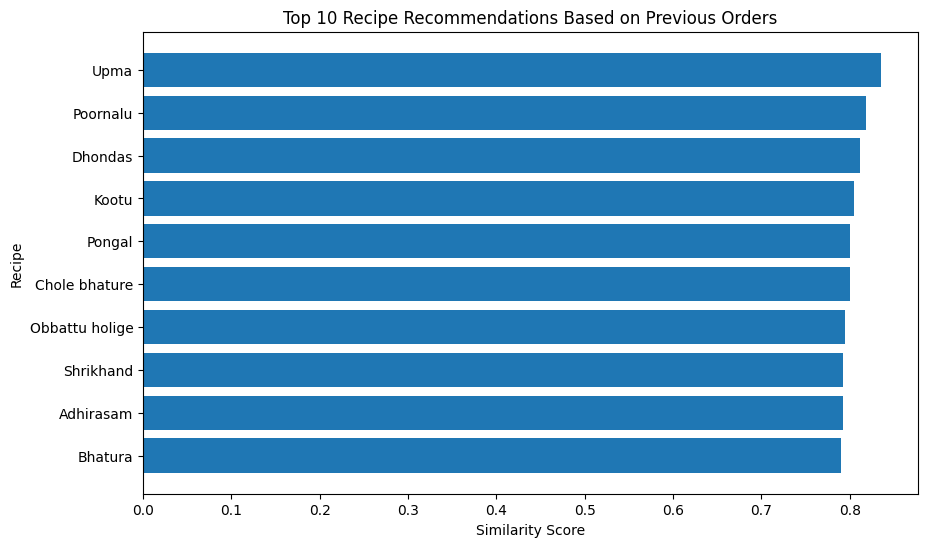

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(names, scores)

plt.xlabel('Similarity Score')
plt.ylabel('Recipe')
plt.title('Top 10 Recipe Recommendations Based on Previous Orders')
plt.gca().invert_yaxis()

plt.show()


# 3. Recommendation system based on user search history

In [46]:
def get_recommendations_indices_from_search_history(user_search , model = embedding_model, embeddings = embeddings, top_k = 10):
  user_search_embeddings = model.encode(user_search)
  n = len(user_search)
  weights = np.arange(1, n + 1)
  weights = weights / weights.sum()
  avg_embedding = np.average(user_search_embeddings, axis= 0, weights=weights)
  avg_embedding = avg_embedding.reshape(1, -1)
  sims = cosine_similarity(avg_embedding, embeddings)
  sims = sims[0]
  indices = np.argsort(sims)[::-1]
  top_indices = indices[:top_k]
  return top_indices


In [49]:
def show_recommendations_from_search_history(user_search, data_frame= df):
  top_indices = get_recommendations_indices_from_search_history(user_search)
  df = data_frame.iloc[top_indices]
  return df


In [39]:
user_previous_search = [
    "spicy chicken curry",
    "paneer butter masala",
    "vegetarian curry",
    "creamy tomato gravy dish",
    "north indian main course"
]

In [50]:
show_recommendations_from_search_history(user_previous_search)

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
74,Bhindi masala,"Ladies finger, garam masala, kasuri methi, tom...",vegetarian,20,30,spicy,main course,Punjab,North
183,Gatta curry,"Yogurt, besan, sauce, garam masala powder, gra...",vegetarian,10,20,spicy,main course,Rajasthan,West
134,Keerai masiyal,"Urad dal, curry leaves, sugar, mustard seeds, ...",vegetarian,-1,-1,spicy,main course,Tamil Nadu,South
132,Kaara kozhambu,"Sesame oil, drumstick, tamarind paste, sambar ...",vegetarian,-1,-1,spicy,main course,Tamil Nadu,South
77,Chana masala,"Chickpeas, tomato paste, garam masala, ginger,...",vegetarian,20,30,spicy,main course,Punjab,North
143,Kuzhambu,"Pearl onions, urad dal, drumsticks, tomato, cu...",vegetarian,5,30,spicy,main course,Tamil Nadu,South
154,Rasam,"Tomato, curry leaves, garlic, mustard seeds, h...",vegetarian,10,35,spicy,main course,-1,South
80,Chicken Tikka masala,"Naan bread, tomato sauce, skinless chicken bre...",non vegetarian,10,50,spicy,main course,Punjab,North
105,Navrattan korma,"Green beans, potatoes, khus khus, low fat, gar...",vegetarian,25,40,spicy,main course,Uttar Pradesh,North
232,Chingri malai curry,"Coconut milk, lobster, fresh green chilli, gin...",non vegetarian,10,40,spicy,main course,West Bengal,East


In [51]:
user_previous_search = [
    "spicy chicken curry with garlic and ginger",
    "paneer butter masala with creamy tomato gravy",
    "vegetarian lentil curry with cumin and turmeric",
    "crispy fried snack with potatoes and peas",
    "sweet dessert made with milk and cardamom",
    "north indian main course with rich gravy",
    "spicy street food snack with chickpea flour",
    "mild creamy curry with paneer and butter",
    "fried appetizer with onions and spices",
    "sweet syrupy dessert with nuts and saffron",
    "healthy vegetarian dish with spinach and lentils",
    "spicy chicken dish with yogurt and chili",
    "crispy pakora with vegetables and spices",
    "rich dessert with condensed milk and pistachios",
    "vegetarian curry with mixed vegetables and spices"
]

In [52]:
show_recommendations_from_search_history(user_previous_search)

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
39,Chikki,"Peanuts, jaggery",vegetarian,10,20,sweet,dessert,Maharashtra,West
61,Shankarpali,"Sugar, ghee, maida flour, semolina",vegetarian,10,35,sweet,dessert,Maharashtra,West
48,Poornalu,"Chana dal, jaggery",vegetarian,240,60,sweet,dessert,Andhra Pradesh,South
54,Kajjikaya,"Rice flour, jaggery, coconut",vegetarian,40,15,sweet,dessert,Andhra Pradesh,South
183,Gatta curry,"Yogurt, besan, sauce, garam masala powder, gra...",vegetarian,10,20,spicy,main course,Rajasthan,West
62,Shrikhand,"Curd, sugar, saffron, cardamom",vegetarian,10,720,sweet,dessert,Maharashtra,West
220,Cheera Doi,"Rice, mango, curd",vegetarian,-1,-1,sweet,dessert,West Bengal,East
49,Pongal,"Rice, jaggery, cashews, ghee",vegetarian,5,20,sweet,dessert,Tamil Nadu,South
184,Gud papdi,"Wheat flour, jaggery, clarified butter, sliced...",vegetarian,10,20,sweet,dessert,Gujarat,West
57,Dhondas,"Cucumber, rava",vegetarian,10,50,sweet,dessert,Maharashtra,West
